# Clase 1: Probabilidad y Estadística para ML

Este laboratorio está pensado para:

1. Calcular medidas de tendencia central y dispersión, y ver cómo un outlier afecta a la media pero la mediana resiste.
2. Visualizar una distribución normal.
3. Calcular correlaciones entre variables de un dataset real.

## 1. Media, mediana, moda y el problema de los outliers

In [1]:
import numpy as np
import pandas as pd

sueldos = pd.Series([1, 1, 2, 2, 2, 100])  # Pensamos que son millones de pesos

print("Media:", sueldos.mean())
print("Mediana:", sueldos.median())
print("Moda:", sueldos.mode()[0])
print("Desvío estándar:", sueldos.std())

Media: 18.0
Mediana: 2.0
Moda: 2
Desvío estándar: 40.17461885320133


La media no representa bien a la mayoría de los sueldos, que están entre 1 y 2 millones. Un único valor extremo la arrastra. La mediana (2) es más resistente a outliers.

## 2. La distribución normal

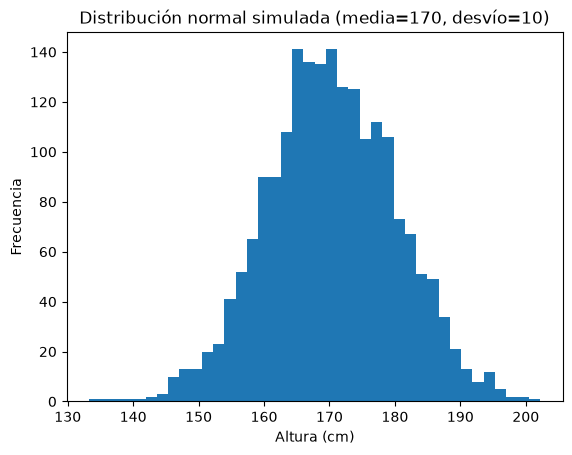

Media de la muestra: 170.31
Desvío de la muestra: 9.9


In [2]:
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(seed=int(time.time()))
muestra = rng.normal(loc=170, scale=10, size=2000)  # ej: alturas en cm

plt.hist(muestra, bins=40)
plt.title("Distribución normal simulada (media=170, desvío=10)")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.show()

print("Media de la muestra:", muestra.mean().round(2))
print("Desvío de la muestra:", muestra.std().round(2))

## 3. Correlación en un dataset real

Volvemos a usar Iris para ver qué variables están más correlacionadas entre sí.

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.drop(columns="target")
df.corr()
#cómo se calcula la correlación?

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


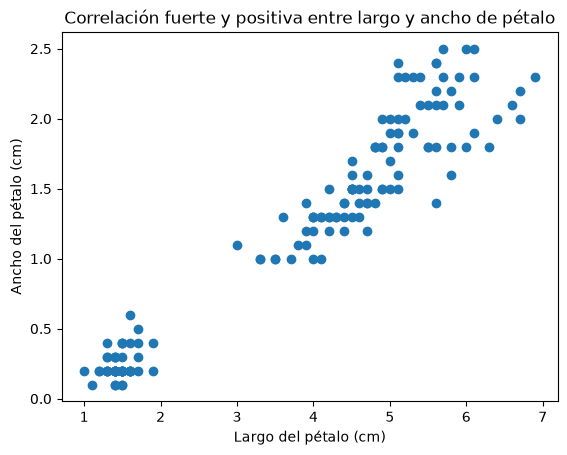

In [4]:
plt.scatter(df["petal length (cm)"], df["petal width (cm)"])
plt.xlabel("Largo del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.title("Correlación fuerte y positiva entre largo y ancho de pétalo")
plt.show()

## Ejercicios

**Ejercicio 1.** Agregá otros outliers a `sueldos` (por ejemplo, otro sueldo de 150) y volvé a calcular media, mediana y desvío estándar. ¿Cómo cambia cada una? ¿Qué pasa si agregamos muchos outliers?

**Ejercicio 2.** Generá una muestra normal con `scale=30` en vez de `10` (misma media). Compará el histograma con el original. ¿Qué le pasa a la "forma" de la campana?

**Ejercicio 3.** Mirando la tabla de `df.corr()`, identificar el par de variables con la correlación más baja. Luego hacer un scatter plot de ese par y confirmar visualmente qué sucede en esa situación (de paso, revisar todos los pares de variables).

**Ejercicio 4.** Dos variables que están muy correlacionadas: la cantidad de heladerías abiertas en una ciudad y la cantidad de ahogamientos en piletas. ¿Hay relación de casualidad entre ellas? ¿Cuál es la variable oculta que explica a ambas?

In [3]:
# Ejercicio 1: tu código acá

import numpy as np
import pandas as pd

sueldos = pd.Series([83, 24, 1, 1, 2, 150, 2, 2, 100, 67, 18, 90])  # Pensamos que son millones de pesos

print("Media:", sueldos.mean())
print("Mediana:", sueldos.median())
print("Moda:", sueldos.mode()[0])
print("Desvío estándar:", sueldos.std())

#moda y mediana se mantienen igual al agregar un 150 como outlier, media pasa a 36.857 y el desvío a 61.92
#esto se mantiene igual incluso al agregar al 150 en el medio del arreglo.

#[83, 24, 1, 1, 2, 150, 2, 2, 100, 67, 18, 90]: media: 45.0; mediana: 21.0; moda: 2; desvio: 50.983

Media: 45.0
Mediana: 21.0
Moda: 2
Desvío estándar: 50.983063141328884


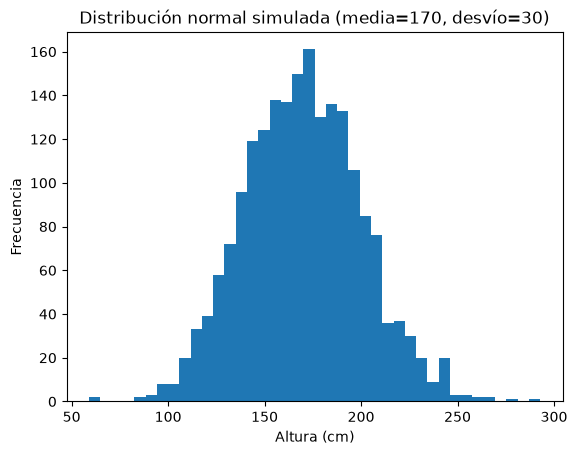

Media de la muestra: 169.96
Desvío de la muestra: 30.31


In [ ]:
# Ejercicio 2: tu código acá

import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(seed=int(time.time()))
muestra = rng.normal(loc=170, scale=30, size=2000)  # ej: alturas en cm

plt.hist(muestra, bins=40)
plt.title("Distribución normal simulada (media=170, desvío=10)")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.show()

print("Media de la muestra:", muestra.mean().round(2))
print("Desvío de la muestra:", muestra.std().round(2))

#la forma de la campana pasa a ser más como un cono.
#pero qué sería en sí la scale? en qué/cómo influye a la gráfica
#es casualidad que el desvío sea casi igual a scale? con el ejemplo de scale=10 pasa lo mismo..
#actualización: la scale es lo mismo q el desvío :D

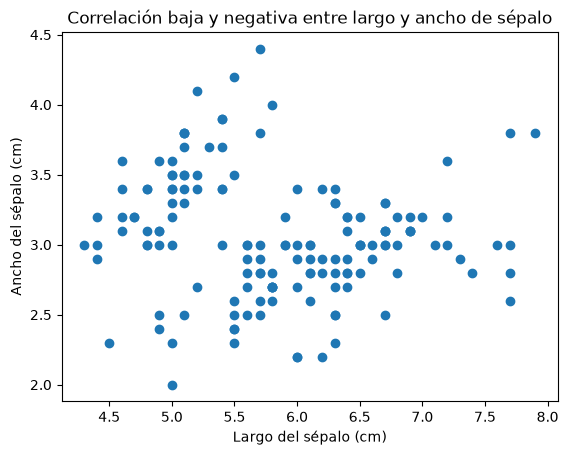

In [19]:
# Ejercicio 3: tu código acá

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.drop(columns="target")

plt.scatter(df["sepal length (cm)"], df["sepal width (cm)"])
plt.xlabel("Largo del sépalo (cm)")
plt.ylabel("Ancho del sépalo (cm)")
plt.title("Correlación baja y negativa entre largo y ancho de sépalo")
plt.show()

In [ ]:
#4:

#no debería haber relación directa entre estas variables (no te ahogas x tomar helado). 
#la variable que explica el cambio en estas dos es "el calor".